# 10. Draft and Playoff Visualizations

Part of the `nuclearff` [User Tutorial](https://nolmacdonald.github.io/nuclearff/tutorial/index.html) notebook series -- every notebook shares one running `./demo` directory and depends on the ones before it having already run. See [README.md](README.md) for the full run order. Run `09_auction_draft_board.ipynb` first.

`04_capturing_a_league.ipynb` persisted draft picks, standings, and playoff bracket matches. This notebook renders three views straight from that stored data: a snake-order draft board grid, a playoff bracket tree, and a manager's draft-order history table. Mirrors the [Draft and Playoff Visualizations](https://nolmacdonald.github.io/nuclearff/tutorial/10_draft_and_playoff_visuals.html) docs page.

## Draft board

`fetch_and_write_draft_picks` fetches (and persists) one draft's picks; `render_draft_board` renders them as a snake-order grid of position-colored pick cards -- one column per draft slot (team), one row per round, matching Sleeper's own draft-room UI:

In [1]:
import polars as pl

from nuclearff.duckdb_io import read_table
from nuclearff.report import render_draft_board
from nuclearff.sleeper import SleeperClient, fetch_and_write_draft_picks

league_id = "1367225133634191360"
db_path = "./demo/data/cache/nuclearff.duckdb"

with SleeperClient(cache_dir="./demo/data/cache") as client:
    drafts = client.get_league_drafts(league_id)
    draft_id = drafts[0]["draft_id"]
    pick_count = fetch_and_write_draft_picks(client, draft_id, db_path)
    draft = client.get_draft(draft_id)
    users = client.get_users(league_id)

settings = draft["settings"]
teams, rounds = settings["teams"], settings["rounds"]
draft_order = draft.get("draft_order") or {}
names_by_user = {u["user_id"]: u["display_name"] for u in users}
names = {
    slot: names_by_user.get(uid) or f"Slot {slot}"
    for uid, slot in draft_order.items()
    if isinstance(slot, int)
}

picks = (
    read_table(db_path, "sleeper_draft_picks")
    .filter(pl.col("draft_id") == draft_id)
    .to_dicts()
)

written = render_draft_board(
    picks,
    names,
    "./demo/data/artifacts/draft_board.png",
    teams=teams,
    rounds=rounds,
    title="NUCLEARFF REDRAFT — Draft Board",
)
print(f"Picks: {pick_count}")
print(f"Draft board: {written}")

Picks: 150
Draft board: demo/data/artifacts/draft_board.png


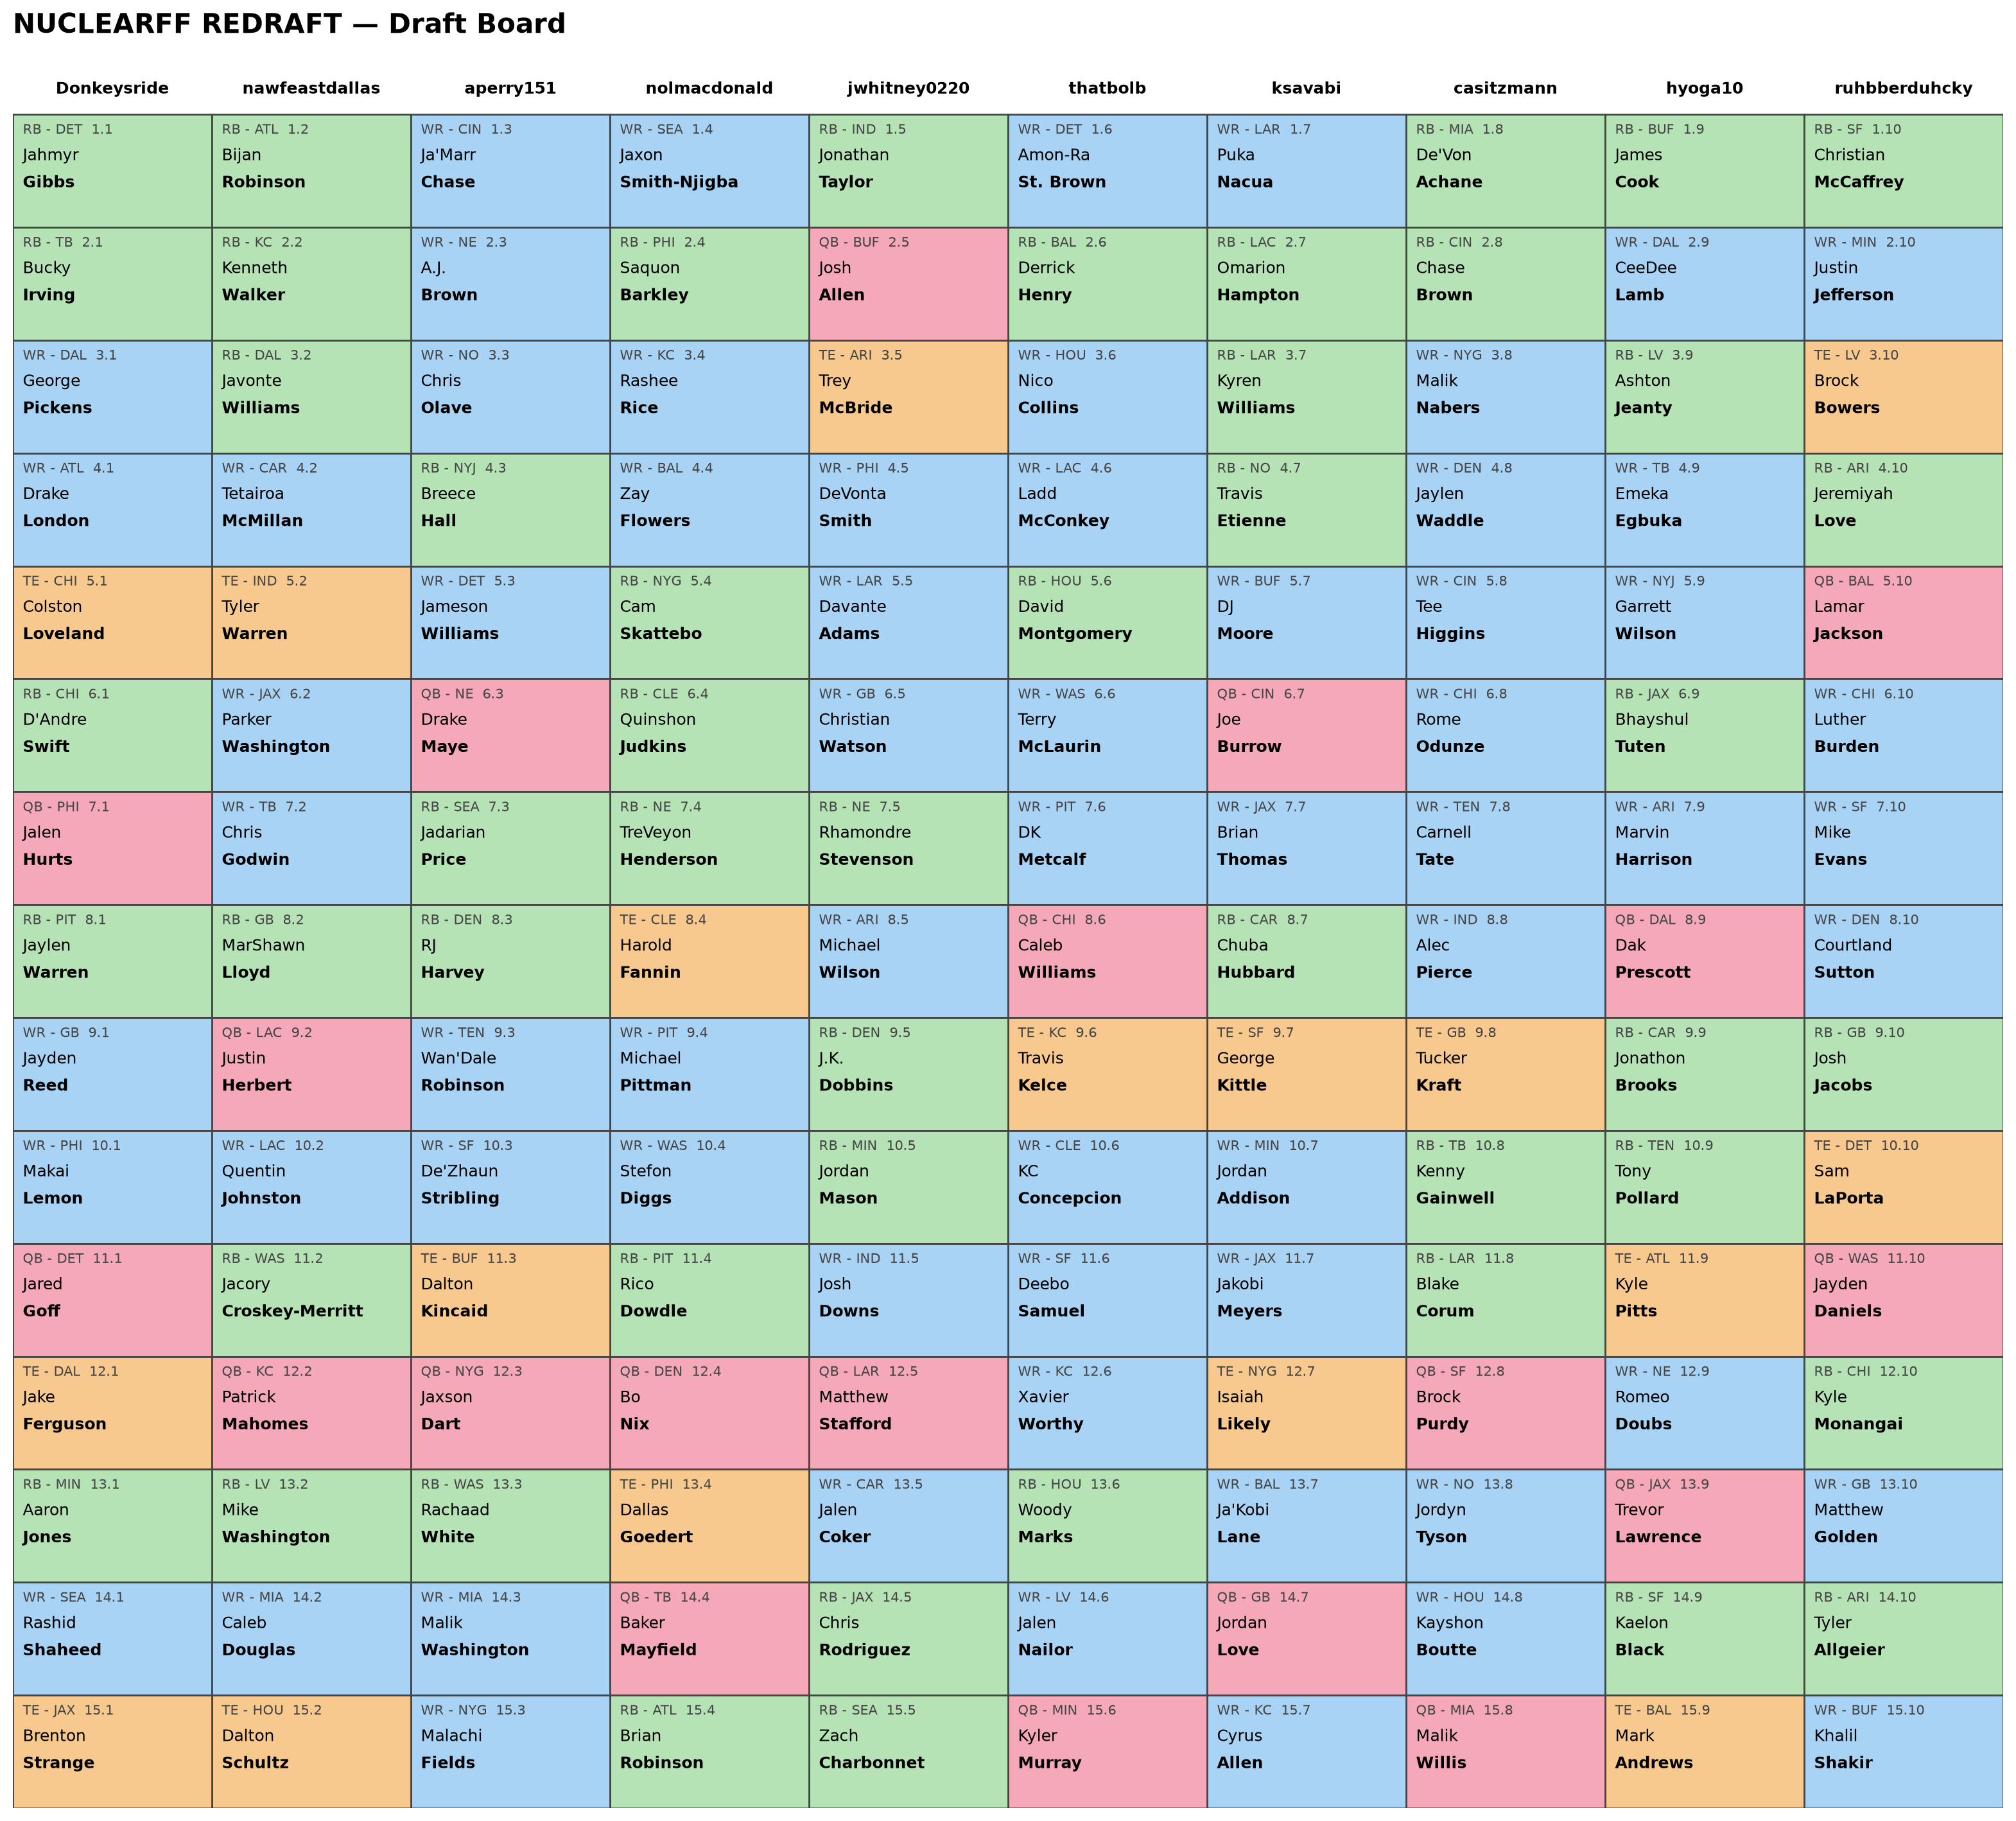

In [2]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/draft_board.png")
)  # Snake-order draft board grid

Each cell shows the pick's position and NFL team, the pick number (e.g. `3.10` -- round 3, draft slot 10), and the player's name. Cell color follows position: green for RB, blue for WR, pink for QB, orange for TE -- confirmed against Sleeper's own draft-room UI; any other position falls back to a neutral gray.

A draft's pick order isn't always a simple alternating snake -- this league's real draft has `settings["reversal_round"] == 3`: round 3 continues round 2's column direction instead of reversing back to round 1's. The grid doesn't compute pick order itself; each pick's column is its own real `draft_slot`, which Sleeper has already resolved correctly, reversal round included. Rendering an in-progress draft (not every round complete yet) is the normal case, not an error -- the grid simply draws however many picks exist so far.

## Playoff bracket

`render_playoff_brackets` reads `sleeper_playoff_matches` and `sleeper_standings` (`04_capturing_a_league.ipynb`'s `fetch_and_write_standings`) and renders a completed season's winners and losers brackets as horizontal tree PNGs:

In [3]:
from nuclearff.report import render_playoff_brackets

season = 2025
season_league_id = "1240509989819273216"  # this league's 2025 league_id

matches = (
    read_table(db_path, "sleeper_playoff_matches")
    .filter((pl.col("league_id") == season_league_id) & (pl.col("season") == season))
    .to_dicts()
)
standings = read_table(db_path, "sleeper_standings").filter(
    (pl.col("league_id") == season_league_id) & (pl.col("season") == season)
)
names = dict(zip(standings["roster_id"], standings["display_name"], strict=True))

written = render_playoff_brackets(
    matches, names, "./demo/data/artifacts/brackets", league_name="NUCLEARFF REDRAFT"
)
for bracket, path in written.items():
    print(f"{bracket.title()} bracket: {path}")

Winners bracket: demo/data/artifacts/brackets/winners_bracket.png
Losers bracket: demo/data/artifacts/brackets/losers_bracket.png


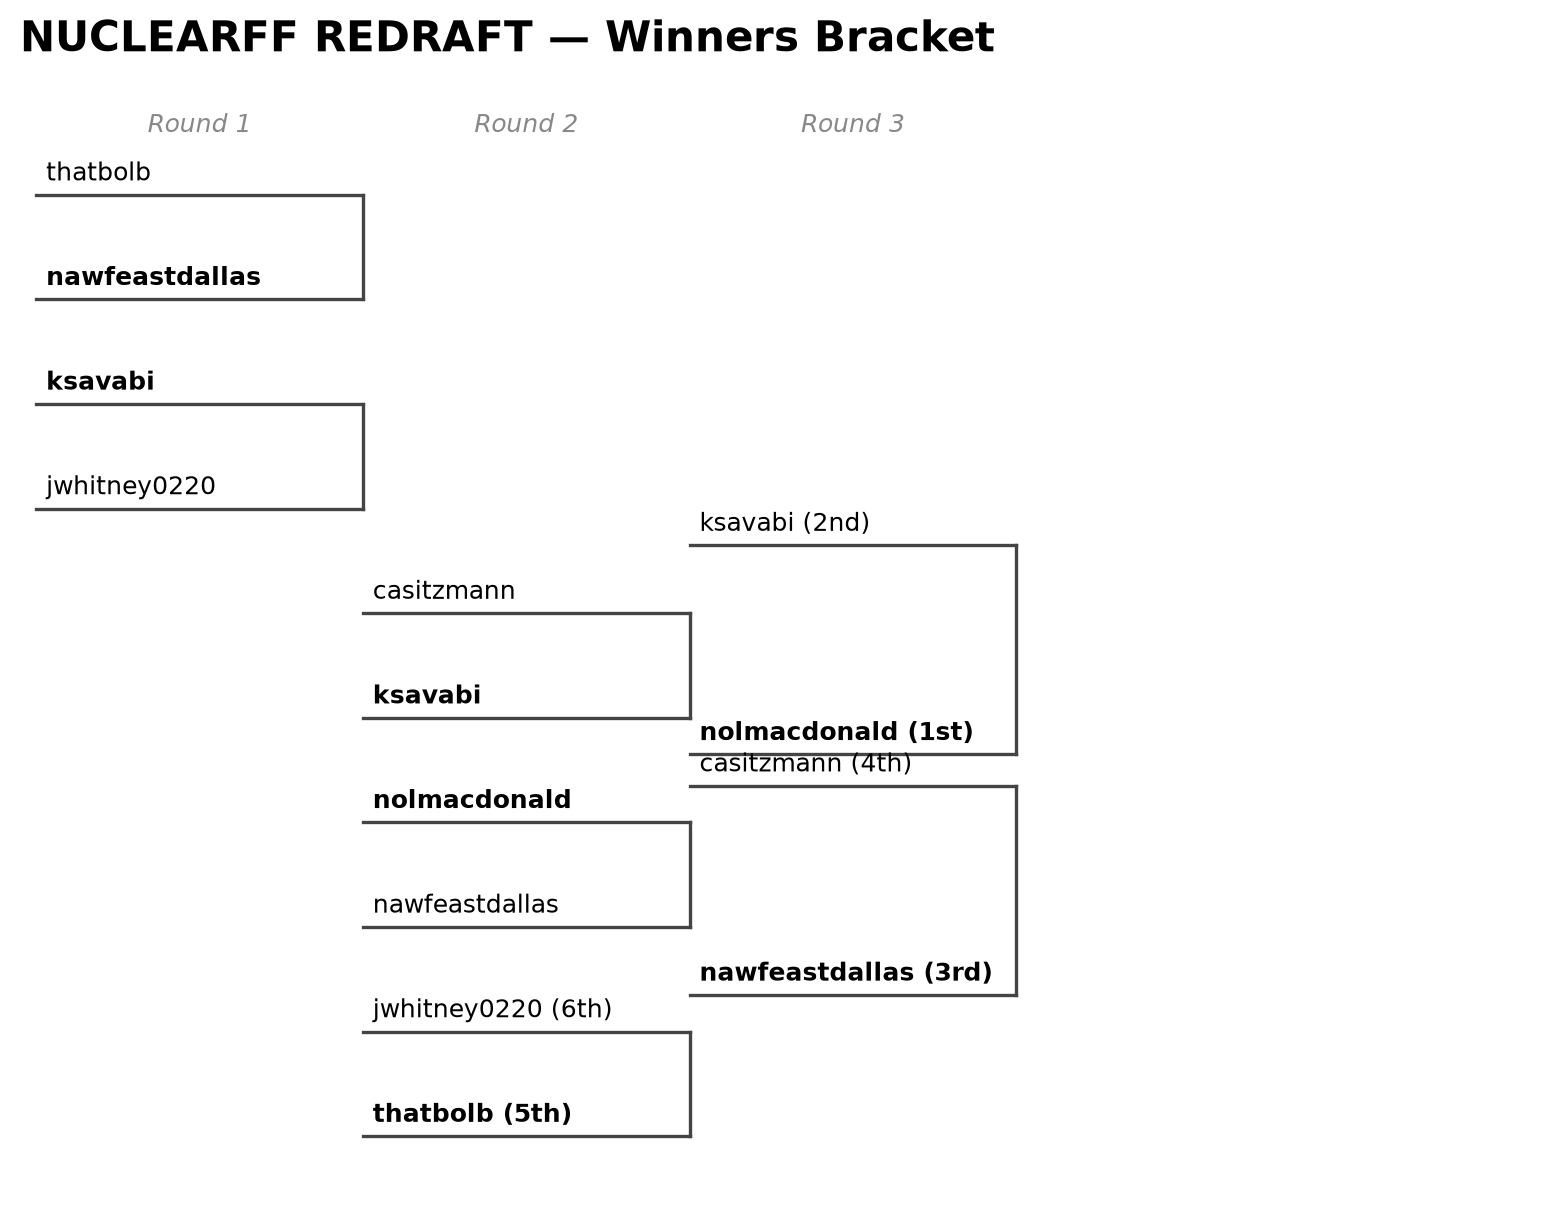

In [4]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/brackets/winners_bracket.png")
)  # Winners playoff bracket tree

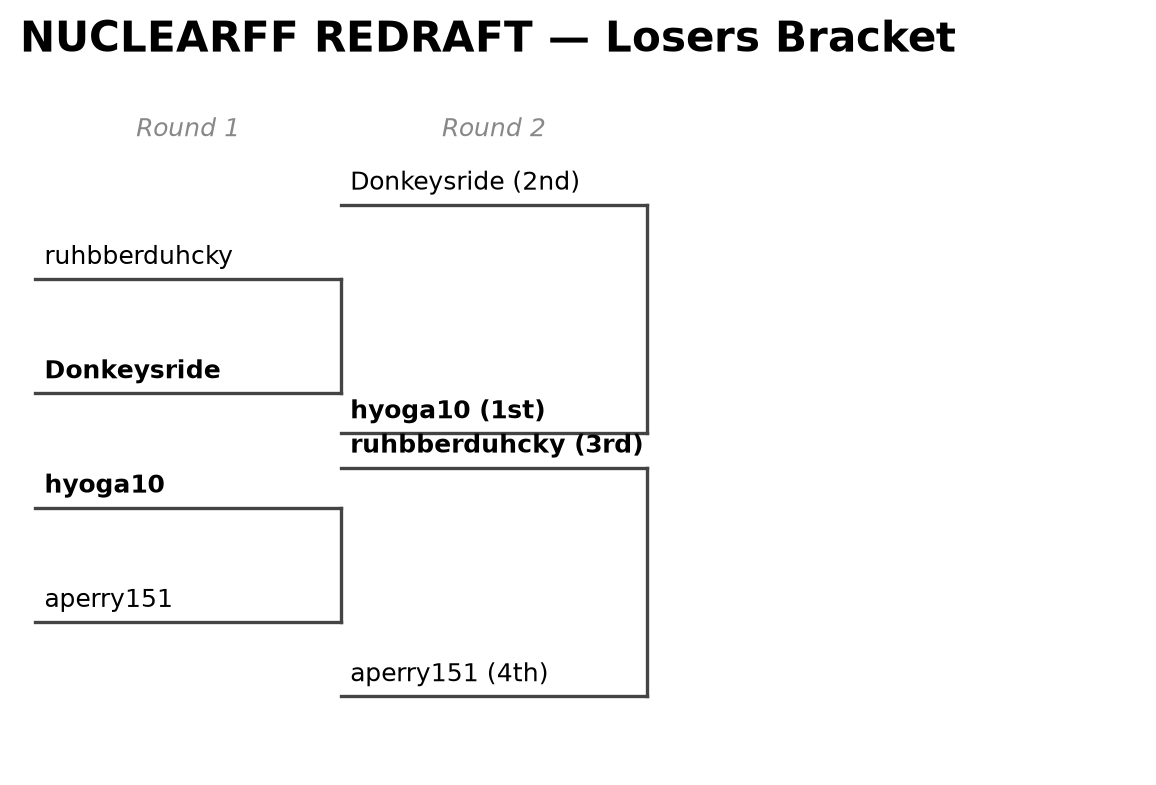

In [5]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/brackets/losers_bracket.png")
)  # Losers playoff bracket tree

That's this league's real, completed 2025 season, each bracket rendered as its own figure (Sleeper treats the two brackets as visually distinct, and so does this). Each leaf/node is labeled with the real team display name; the winner of each match renders bold; and a match carrying a placement (the championship, the third-place game) appends the resulting rank, e.g. `nolmacdonald (1st)`.

A Sleeper bracket isn't a similarity-clustering dendrogram -- it's a fixed-shape single-elimination tree keyed by `t1_from`/`t2_from` match references, so a later round's participant resolves through an earlier match's *winner or loser* rather than a fresh pair of roster ids. This league's own bracket has a real wrinkle: the championship and the third-place game split from the exact same pair of semifinal matches, landing on the same computed tree position -- the renderer nudges the two apart by their own box height so neither the lines nor the labels overlap.

## Draft order history

`draft_order_stats` summarizes a manager's draft-slot history across every season on file -- average position, and how often they landed first or last overall:

In [6]:
from nuclearff.sleeper import (
    draft_order_stats,
    fetch_and_write_all_drafts,
    walk_league_chain,
)

with SleeperClient(cache_dir="./demo/data/cache") as client:
    all_leagues = walk_league_chain(client, league_id, max_seasons=20)
    n = fetch_and_write_all_drafts(client, all_leagues, db_path)
print(f"Draft picks: {n}")

all_picks = read_table(db_path, "sleeper_draft_picks")
all_standings = read_table(db_path, "sleeper_standings")
stats = draft_order_stats(all_picks, all_standings)
stats.sort("avg_draft_position").head(5)

Draft picks: 900


manager,seasons_drafted,avg_draft_position,times_first_pick,times_last_pick
str,u32,f64,u32,u32
"""BigCookie96""",3,2.0,1,0
"""bigshett""",1,3.0,0,0
"""Donkeysride""",4,3.25,1,0
"""ruhbberduhcky""",4,3.5,2,1
"""macbuffet66""",2,4.0,0,0


By default (as with `report trades`/`report wins` in later chapters), only managers currently rostered in the league's own season appear -- pass `--all-users`'s Python equivalent by *not* filtering `standings` to the current `league_id` before calling `draft_order_stats`, exactly as done above, to include every manager across the league's full history instead.

## What's Next

Point-in-time projections and draft snapshots are half the picture. `11_simulation.ipynb` turns a single projected mean into a full range of plausible season outcomes.

## See Also

- `04_capturing_a_league.ipynb` -- where `sleeper_draft_picks`/`sleeper_playoff_matches`/`sleeper_standings` come from.
- [Draft and Playoff Visualizations](https://nolmacdonald.github.io/nuclearff/tutorial/10_draft_and_playoff_visuals.html) -- the matching docs page.